In [25]:
# Import tools
import itertools
import json
import shutil
import mpmath as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from IPython.display import display
from google.colab import files


In [26]:
# Set experiment values
plt.rc("text",usetex=False)
plt.rc("font",family="serif")
plt.rc("mathtext",fontset="cm")
plt.rc("font",size=13)
plt.rc("axes",labelsize=14)
plt.rc("xtick",labelsize=11)
plt.rc("ytick",labelsize=11)
plt.rc("legend",fontsize=11)
plt.rc("xtick",top=False,direction="out")
plt.rc("ytick",right=False,direction="out")
plt.rc("xtick.major",size=4.5,width=0.9)
plt.rc("ytick.major",size=4.5,width=0.9)
plt.rc("lines",linewidth=1.8,markersize=4.5,markeredgewidth=0.8)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
out = Path("structure")
shutil.rmtree(out,ignore_errors=True)
out.mkdir()
n = 8
obs = np.array([0.0,0.25,0.5])
horizon = 1.0
tol = 1e-8
familyhorizons = [1.0,2.0,4.0]
families = ["path","cycle","star","complete","barbell","ladder"]
targetkinds = ["uniform","region","weighted","pair"]
bridges = np.array([0.0,0.0001,0.001,0.01,0.02,0.05,0.10,0.15,0.25,0.50,1.00,2.00])
localizations = np.linspace(0,1,11)
bridge0 = 0.15
local0 = 0.5


In [27]:
# Build graph families
def familygraph(name):
    if name=="path":
        G = nx.path_graph(n)
    elif name=="cycle":
        G = nx.cycle_graph(n)
    elif name=="star":
        G = nx.star_graph(n-1)
    elif name=="complete":
        G = nx.complete_graph(n)
    elif name=="barbell":
        G = nx.barbell_graph(n//2,0)
    elif name=="ladder":
        G = nx.ladder_graph(n//2)
    W = nx.to_numpy_array(G,dtype=float)
    if name=="barbell":
        W[n//2-1,n//2] = 0.15
        W[n//2,n//2-1] = 0.15
    return W

def weightedbarbell(bridge):
    W = np.zeros((n,n))
    for start in [0,4]:
        for i in range(start,start+4):
            for j in range(i+1,start+4):
                W[i,j] = 1
                W[j,i] = 1
    W[3,4] = bridge
    W[4,3] = bridge
    return W


In [28]:
# Build target families
def familytarget(kind):
    c = np.zeros(n)
    if kind=="uniform":
        c[:] = 1/n
    elif kind=="region":
        c[:n//2] = 1/(n//2)
    elif kind=="weighted":
        values = np.arange(1,n//2+1,dtype=float)
        c[:n//2] = values/values.sum()
    elif kind=="pair":
        c[0] = 0.5
        c[-1] = 0.5
    return c

def localizedtarget(level):
    globaltarget = np.ones(n)/n
    localtarget = np.array([0.4,0.3,0.2,0.1,0,0,0,0],dtype=float)
    return (1-level)*globaltarget+level*localtarget


In [29]:
# Build diffusion models
def multiplicity(values):
    groups = []
    for value in values:
        if len(groups)==0 or abs(value-groups[-1][0])>1e-8*max(1,abs(value)):
            groups.append([value,1])
        else:
            groups[-1][1] += 1
    return max(group[1] for group in groups)

def buildmodel(W,c,targethorizon=1.0):
    L = np.diag(W.sum(axis=1))-W
    values,vectors = np.linalg.eigh(L)
    scale = values[-1]
    times = obs/scale
    tau = targethorizon/scale
    decay = np.exp(-np.outer(times,values))
    blocks = [decay*vectors[v,:] for v in range(n)]
    infos = [block.T@block for block in blocks]
    total = np.sum(infos,axis=0)
    beta = 0.01*np.trace(total)/n
    g = np.exp(-tau*values)*(vectors.T@c)
    return {"W":W,"L":L,"values":values,"vectors":vectors,"times":times,"tau":tau,"blocks":blocks,"infos":infos,"beta":beta,"g":g,"n":n}


In [30]:
# Define sensor metrics
def measurement(sensors,model):
    if len(sensors)==0:
        return np.zeros((0,n))
    return np.vstack([model["blocks"][v] for v in sensors])

def basis(B):
    if B.size==0:
        return np.zeros((B.shape[1],0)),0
    _,values,vh = np.linalg.svd(B,full_matrices=False)
    if len(values)==0 or values[0]==0:
        return np.zeros((B.shape[1],0)),0
    cut = 100*max(B.shape)*np.finfo(float).eps*values[0]
    rank = int((values>cut).sum())
    return vh[:rank].T,rank

def spanerror(sensors,model):
    B = measurement(sensors,model)
    V,rank = basis(B)
    if rank==0:
        return 1.0
    g = model["g"]
    residual = g-V@(V.T@g)
    return np.linalg.norm(residual)/np.linalg.norm(g)

def riskparts(sensors,model):
    B = measurement(sensors,model)
    g = model["g"]
    beta = model["beta"]
    if B.shape[0]==0:
        return 1.0,0.0,1.0
    C = B@B.T+beta*np.eye(B.shape[0])
    w = np.linalg.solve(C,B@g)
    residual = B.T@w-g
    mismatch = np.linalg.norm(residual)/np.linalg.norm(g)
    penalty = np.sqrt(beta)*np.linalg.norm(w)/np.linalg.norm(g)
    return mismatch,penalty,np.sqrt(mismatch**2+penalty**2)

def setrank(sensors,model):
    return basis(measurement(sensors,model))[1]

def smallsingular(sensors,model):
    B = measurement(sensors,model)
    if basis(B)[1]<n:
        return 0.0
    return np.linalg.svd(B,compute_uv=False)[-1]

def weightnorm(sensors,model):
    B = measurement(sensors,model)
    if B.shape[0]==0:
        return np.nan
    w = np.linalg.lstsq(B.T,model["g"],rcond=None)[0]
    return np.linalg.norm(w)

def closedrisk(sensors,model):
    B = measurement(sensors,model)
    g = model["g"]
    beta = model["beta"]
    C = B.T@B+beta*np.eye(n)
    return np.sqrt(beta*g@np.linalg.solve(C,g)/(g@g))


In [31]:
# Enumerate sensor subsets
allsets = [sensors for size in range(n+1) for sensors in itertools.combinations(range(n),size)]

def enumeratecase(model):
    rows = []
    for sensors in allsets:
        mismatch,penalty,risk = riskparts(sensors,model)
        rows.append({"sensors":sensors,"budget":len(sensors),"span":spanerror(sensors,model),"mismatch":mismatch,"penalty":penalty,"risk":risk,"rank":setrank(sensors,model),"smin":smallsingular(sensors,model),"weightnorm":weightnorm(sensors,model)})
    return pd.DataFrame(rows)


In [32]:
# Define greedy methods
def greedy(table,kind):
    riskmap = dict(zip(table["sensors"],table["risk"]))
    spanmap = dict(zip(table["sensors"],table["span"]))
    rankmap = dict(zip(table["sensors"],table["rank"]))
    selected = ()
    rows = [{"budget":0,"added":np.nan,"sensors":selected,"span":1.0,"risk":1.0,"rank":0}]
    while len(selected)<n:
        candidates = [tuple(sorted(selected+(v,))) for v in range(n) if v not in selected]
        if kind=="risk":
            best = min(riskmap[s] for s in candidates)
            tied = [s for s in candidates if np.isclose(riskmap[s],best,rtol=1e-12,atol=1e-14)]
        else:
            bestspan = min(spanmap[s] for s in candidates)
            tiedspan = [s for s in candidates if np.isclose(spanmap[s],bestspan,rtol=1e-10,atol=1e-12)]
            bestrisk = min(riskmap[s] for s in tiedspan)
            tied = [s for s in tiedspan if np.isclose(riskmap[s],bestrisk,rtol=1e-12,atol=1e-14)]
        previous = set(selected)
        selected = min(tied)
        added = next(v for v in selected if v not in previous)
        rows.append({"budget":len(selected),"added":added,"sensors":selected,"span":spanmap[selected],"risk":riskmap[selected],"rank":rankmap[selected]})
    return pd.DataFrame(rows)

def firstexact(history):
    exact = history[history["span"]<=tol]
    return int(exact["budget"].iloc[0]) if len(exact)>0 else np.nan


In [33]:
# Define structural analysis
def oneexchange(sensors,riskmap):
    current = tuple(sorted(sensors))
    currentrisk = riskmap[current]
    swaps = 0
    while True:
        choices = []
        for old in current:
            for new in range(n):
                if new not in current:
                    trial = tuple(sorted(tuple(v for v in current if v!=old)+(new,)))
                    choices.append((riskmap[trial],trial))
        if len(choices)==0:
            break
        bestrisk = min(choice[0] for choice in choices)
        if bestrisk>=currentrisk-1e-12:
            break
        tied = [choice for choice in choices if np.isclose(choice[0],bestrisk,rtol=1e-12,atol=1e-14)]
        currentrisk,current = min(tied,key=lambda item:item[1])
        swaps += 1
    return current,swaps,currentrisk

def analyzecase(bridge,level,details=False):
    model = buildmodel(weightedbarbell(bridge),localizedtarget(level),horizon)
    table = enumeratecase(model)
    exact = table[table["span"]<=tol]
    targetbudget = int(exact["budget"].min())
    exactsets = exact[exact["budget"]==targetbudget]
    bestexact = exactsets.sort_values(["risk","weightnorm","sensors"]).iloc[0]
    full = table[table["rank"]==n]
    fullbudget = int(full["budget"].min())
    fullsets = full[full["budget"]==fullbudget]
    maxsmin = fullsets["smin"].max()
    bestfull = fullsets[np.isclose(fullsets["smin"],maxsmin,rtol=1e-8,atol=1e-10)].sort_values(["risk","sensors"]).iloc[0]
    riskhist = greedy(table,"risk")
    spanhist = greedy(table,"span")
    riskexact = firstexact(riskhist)
    spanexact = firstexact(spanhist)
    targetgroup = table[table["budget"]==targetbudget]
    bestrisk = targetgroup.sort_values(["risk","sensors"]).iloc[0]
    previousspan = np.nan if targetbudget==0 else table[table["budget"]==targetbudget-1]["span"].min()
    riskmap = dict(zip(table["sensors"],table["risk"]))
    compare = []
    for budget in range(n+1):
        riskrow = riskhist[riskhist["budget"]==budget].iloc[0]
        group = table[table["budget"]==budget]
        best = group.sort_values(["risk","sensors"]).iloc[0]
        refined,swaps,refinedrisk = oneexchange(riskrow["sensors"],riskmap)
        compare.append({"budget":budget,"riskset":riskrow["sensors"],"riskvalue":riskrow["risk"],"bestset":best["sensors"],"bestvalue":best["risk"],"riskgap":riskrow["risk"]-best["risk"],"refinedset":refined,"refinedvalue":refinedrisk,"refinedgap":refinedrisk-best["risk"],"swaps":swaps})
    compare = pd.DataFrame(compare)
    values = model["values"]
    lower = max(int(np.ceil(n/len(obs))),multiplicity(values))
    summary = {"bridge":bridge,"localization":level,"lambda2":values[1],"lmax":values[-1],"normgap":values[1]/values[-1],"beta":model["beta"],"multiplicity":multiplicity(values),"lower":lower,"targetbudget":targetbudget,"fullbudget":fullbudget,"riskexact":riskexact,"spanexact":spanexact,"riskexcess":riskexact-targetbudget,"spanexcess":spanexact-targetbudget,"previousspan":previousspan,"exactspan":bestexact["span"],"bestexactset":bestexact["sensors"],"bestexactrisk":bestexact["risk"],"bestexactnorm":bestexact["weightnorm"],"fullset":bestfull["sensors"],"fullsmin":bestfull["smin"],"fullrisk":bestfull["risk"],"bestset":bestrisk["sensors"],"bestrisk":bestrisk["risk"],"exactcost":bestexact["risk"]-bestrisk["risk"],"maxriskgap":compare["riskgap"].max(),"worstbudget":int(compare.loc[compare["riskgap"].idxmax(),"budget"]),"maxrefinedgap":compare["refinedgap"].max(),"totalswaps":int(compare["swaps"].sum())}
    if details:
        return summary,table,riskhist,spanhist,compare
    return summary


In [34]:
# Verify metric formulas
baseline = buildmodel(weightedbarbell(bridge0),localizedtarget(local0),horizon)
basetable = enumeratecase(baseline)
checks = []
for sensors in allsets:
    direct = riskparts(sensors,baseline)[2]
    closed = closedrisk(sensors,baseline)
    checks.append(abs(direct-closed))
assert max(checks)<1e-12
print("Subsets checked:",len(allsets))
print("Maximum risk-formula difference:",f"{max(checks):.3e}")


Subsets checked: 256
Maximum risk-formula difference: 8.882e-15


In [35]:
# Run graph family sweep
graphrows = []
caserows = []
for name in families:
    W = familygraph(name)
    base = buildmodel(W,familytarget("uniform"),1.0)
    table = enumeratecase(base)
    full = table[table["rank"]==n]
    fullbudget = int(full["budget"].min())
    fullsmin = full[full["budget"]==fullbudget]["smin"].max()
    lower = max(int(np.ceil(n/len(obs))),multiplicity(base["values"]))
    graphrows.append({"graph":name,"nodes":n,"edges":int(np.count_nonzero(np.triu(W,1))),"eigenvalues":len(np.unique(np.round(base["values"],8))),"multiplicity":multiplicity(base["values"]),"rowbound":int(np.ceil(n/len(obs))),"bound":lower,"full":fullbudget,"smin":fullsmin})
    for kind in targetkinds:
        for targethorizon in familyhorizons:
            model = buildmodel(W,familytarget(kind),targethorizon)
            table = enumeratecase(model)
            exact = table[table["span"]<=tol]
            exactbudget = int(exact["budget"].min())
            bestexact = exact[exact["budget"]==exactbudget].sort_values(["risk","sensors"]).iloc[0]
            history = greedy(table,"risk")
            greedybudget = firstexact(history)
            chosen = history[history["budget"]==greedybudget].iloc[0]
            caserows.append({"graph":name,"target":kind,"horizon":targethorizon,"exact":exactbudget,"full":fullbudget,"greedy":greedybudget,"save":fullbudget-exactbudget,"excess":greedybudget-exactbudget,"rank":int(chosen["rank"]),"residual":bestexact["span"],"targetset":bestexact["sensors"],"greedyset":chosen["sensors"]})
familygraphs = pd.DataFrame(graphrows)
familycases = pd.DataFrame(caserows)
familysummary = familycases.groupby(["graph","target"],as_index=False).agg(exact=("exact","mean"),full=("full","mean"),greedy=("greedy","mean"),save=("save","mean"),excess=("excess","mean"))
assert len(familycases)==72
assert int((familycases["exact"]<familycases["full"]).sum())==42
assert int((familycases["excess"]==0).sum())==62
assert int((familygraphs["bound"]==familygraphs["full"]).sum())==6
display(familysummary.round(3))


,graph,target,exact,full,greedy,save,excess
0,barbell,pair,2.0,5.0,2.333,3.0,0.333
1,barbell,region,2.0,5.0,4.000,3.0,2.000
2,barbell,uniform,2.0,5.0,2.000,3.0,0.000
3,barbell,weighted,3.0,5.0,3.333,2.0,0.333
4,complete,pair,2.0,7.0,2.000,5.0,0.000
5,complete,region,4.0,7.0,4.000,3.0,0.000
6,complete,uniform,1.0,7.0,1.000,6.0,0.000
7,complete,weighted,4.0,7.0,4.000,3.0,0.000
8,cycle,pair,3.0,3.0,3.000,0.0,0.000
9,cycle,region,3.0,3.0,3.000,0.0,0.000


In [36]:
# Run weighted barbell sweep
rows = []
for bridge in bridges:
    print("Bridge:",bridge)
    for level in localizations:
        rows.append(analyzecase(float(bridge),float(level)))
structure = pd.DataFrame(rows)
baseline_summary,baseline_subsets,baseline_risk,baseline_span,baseline_compare = analyzecase(bridge0,local0,details=True)
print("Cases:",len(structure))
display(structure.head())


Bridge: 0.0
Bridge: 0.0001
Bridge: 0.001
Bridge: 0.01
Bridge: 0.02
Bridge: 0.05
Bridge: 0.1
Bridge: 0.15
Bridge: 0.25
Bridge: 0.5
Bridge: 1.0
Bridge: 2.0
Cases: 132


,bridge,localization,lambda2,lmax,normgap,beta,multiplicity,lower,targetbudget,fullbudget,...,fullset,fullsmin,fullrisk,bestset,bestrisk,exactcost,maxriskgap,worstbudget,maxrefinedgap,totalswaps
0,0.0,0.0,-2.289226e-29,4.0,-5.723064e-30,0.022308,6,6,2,6,...,"(0, 2, 3, 4, 5, 6)",0.126674,0.330336,"(0, 4)",0.597165,0.000000,1.110223e-16,1,1.110223e-16,0
1,0.0,0.1,-2.289226e-29,4.0,-5.723064e-30,0.022308,6,6,4,6,...,"(0, 1, 2, 4, 5, 6)",0.126674,0.321184,"(0, 1, 5, 6)",0.435411,0.014416,1.110223e-16,4,1.110223e-16,0
2,0.0,0.2,-2.289226e-29,4.0,-5.723064e-30,0.022308,6,6,4,6,...,"(0, 1, 2, 4, 5, 6)",0.126674,0.310935,"(0, 1, 2, 4)",0.415538,0.000000,1.110223e-16,2,1.110223e-16,0
3,0.0,0.3,-2.289226e-29,4.0,-5.723064e-30,0.022308,6,6,4,6,...,"(0, 1, 2, 5, 6, 7)",0.126674,0.300175,"(0, 1, 2, 4)",0.381425,0.000000,5.551115e-17,3,5.551115e-17,0
4,0.0,0.4,-2.289226e-29,4.0,-5.723064e-30,0.022308,6,6,4,6,...,"(0, 1, 2, 4, 5, 7)",0.126674,0.289485,"(0, 1, 2, 4)",0.349170,0.000000,5.551115e-17,6,5.551115e-17,0


In [37]:
# Summarize structural results
budgetcounts = structure["targetbudget"].value_counts().to_dict()
excesscounts = structure["riskexcess"].value_counts().to_dict()
summary = pd.DataFrame([
    {"quantity":"Structural cases","value":len(structure)},
    {"quantity":"Exact target budget 2","value":budgetcounts.get(2,0)},
    {"quantity":"Exact target budget 3","value":budgetcounts.get(3,0)},
    {"quantity":"Exact target budget 4","value":budgetcounts.get(4,0)},
    {"quantity":"Risk-greedy exact matches","value":excesscounts.get(0,0)},
    {"quantity":"Risk-greedy excess 1","value":excesscounts.get(1,0)},
    {"quantity":"Risk-greedy excess 2","value":excesscounts.get(2,0)},
    {"quantity":"Global-risk failures","value":int((structure["maxriskgap"]>1e-10).sum())},
    {"quantity":"Failures after one-exchange","value":int((structure["maxrefinedgap"]>1e-10).sum())},
    {"quantity":"Exact-stable disagreements","value":int((structure["exactcost"]>1e-10).sum())}
])
display(summary)


,quantity,value
0,Structural cases,132
1,Exact target budget 2,12
2,Exact target budget 3,111
3,Exact target budget 4,9
4,Risk-greedy exact matches,52
5,Risk-greedy excess 1,76
6,Risk-greedy excess 2,4
7,Global-risk failures,37
8,Failures after one-exchange,3
9,Exact-stable disagreements,72


In [38]:
# Measure weak bridge scaling
bridgeframe = structure[np.isclose(structure["localization"],local0)].sort_values("bridge").copy()
weak = bridgeframe[(bridgeframe["bridge"]>0)&(bridgeframe["bridge"]<=0.01)].copy()
weak["bridge_times_norm"] = weak["bridge"]*weak["bestexactnorm"]
weak["smin_over_bridge"] = weak["fullsmin"]/weak["bridge"]
normslope = np.polyfit(np.log10(weak["bridge"]),np.log10(weak["bestexactnorm"]),1)[0]
sminslope = np.polyfit(np.log10(weak["bridge"]),np.log10(weak["fullsmin"]),1)[0]
print("Estimator-norm log slope:",f"{normslope:.4f}")
print("Singular-value log slope:",f"{sminslope:.4f}")
display(weak[["bridge","targetbudget","bestexactnorm","bridge_times_norm","fullsmin","smin_over_bridge"]])


Estimator-norm log slope: -0.9919
Singular-value log slope: 0.9993


,bridge,targetbudget,bestexactnorm,bridge_times_norm,fullsmin,smin_over_bridge
16,0.0001,3,45019.955770,4.501996,0.000004,0.038978
27,0.0010,3,4517.533601,4.517534,0.000039,0.038967
38,0.0100,3,467.353087,4.673531,0.000389,0.038860


In [39]:
# Define high precision audit
def highgraph(bridge,digits=70):
    mp.mp.dps = digits
    b = mp.mpf(str(float(bridge)))
    A = mp.zeros(n,n)
    for start in [0,4]:
        for i in range(start,start+4):
            for j in range(i+1,start+4):
                A[i,j] = 1
                A[j,i] = 1
    A[3,4] = b
    A[4,3] = b
    L = mp.zeros(n,n)
    for i in range(n):
        degree = mp.fsum(A[i,j] for j in range(n))
        for j in range(n):
            L[i,j] = degree if i==j else -A[i,j]
    values,_ = mp.eigsy(L)
    scale = values[n-1]
    effects = [mp.expm(-(mp.mpf(str(float(value)))/scale)*L) for value in obs]
    targeteffect = mp.expm(-(mp.mpf(str(horizon))/scale)*L)
    return {"effects":effects,"targeteffect":targeteffect,"digits":digits}

def highresidual(cache,level,sensors):
    ell = mp.mpf(str(float(level)))
    globaltarget = [mp.mpf(1)/n for _ in range(n)]
    localtarget = [mp.mpf("0.4"),mp.mpf("0.3"),mp.mpf("0.2"),mp.mpf("0.1"),mp.mpf(0),mp.mpf(0),mp.mpf(0),mp.mpf(0)]
    c = mp.matrix([(1-ell)*globaltarget[i]+ell*localtarget[i] for i in range(n)])
    g = cache["targeteffect"].T*c
    rows = [[effect[v,j] for j in range(n)] for v in sensors for effect in cache["effects"]]
    B = mp.matrix(rows).T
    U,values,_ = mp.svd(B)
    cut = mp.mpf(10)**(-(cache["digits"]//2))
    rank = sum(values[i]>cut for i in range(values.rows))
    projection = mp.zeros(n,1)
    for j in range(rank):
        direction = U[:,j]
        projection += direction*((direction.T*g)[0])
    residual = mp.norm(g-projection)/mp.norm(g)
    smallest = mp.mpf(0) if rank==0 else values[rank-1]
    return rank,float(residual),float(smallest)


In [40]:
# Audit exact sets precisely
cache = {}
for bridge in bridges:
    print("Caching bridge:",bridge)
    cache[float(bridge)] = highgraph(float(bridge))
rows = []
for row in structure.itertuples():
    rank,residual,smallest = highresidual(cache[float(row.bridge)],row.localization,row.bestexactset)
    rows.append({"bridge":row.bridge,"localization":row.localization,"targetbudget":row.targetbudget,"exactset":row.bestexactset,"double_span":row.exactspan,"previous_span":row.previousspan,"high_rank":rank,"high_span":residual,"high_smallest":smallest,"weightnorm":row.bestexactnorm,"fullsmin":row.fullsmin})
highprecision = pd.DataFrame(rows)
print("Cases audited:",len(highprecision))
print("Largest high-precision residual:",f'{highprecision["high_span"].max():.3e}')


Caching bridge: 0.0
Caching bridge: 0.0001
Caching bridge: 0.001
Caching bridge: 0.01
Caching bridge: 0.02
Caching bridge: 0.05
Caching bridge: 0.1
Caching bridge: 0.15
Caching bridge: 0.25
Caching bridge: 0.5
Caching bridge: 1.0
Caching bridge: 2.0
Cases audited: 132
Largest high-precision residual: 5.899e-70


In [41]:
# Verify structural results
assert len(structure)==132
assert len(highprecision)==132
assert budgetcounts.get(2,0)==12 and budgetcounts.get(3,0)==111 and budgetcounts.get(4,0)==9
assert excesscounts.get(0,0)==52 and excesscounts.get(1,0)==76 and excesscounts.get(2,0)==4
assert int((structure["maxriskgap"]>1e-10).sum())==37
assert int((structure["maxrefinedgap"]>1e-10).sum())==3
assert int((structure["exactcost"]>1e-10).sum())==72
assert np.all(structure["targetbudget"]<=structure["fullbudget"])
assert np.all(structure["spanexact"]==structure["targetbudget"])
assert highprecision["high_span"].max()<1e-50
assert highprecision["previous_span"].min()>1e-3
print("All structural checks passed")


All structural checks passed


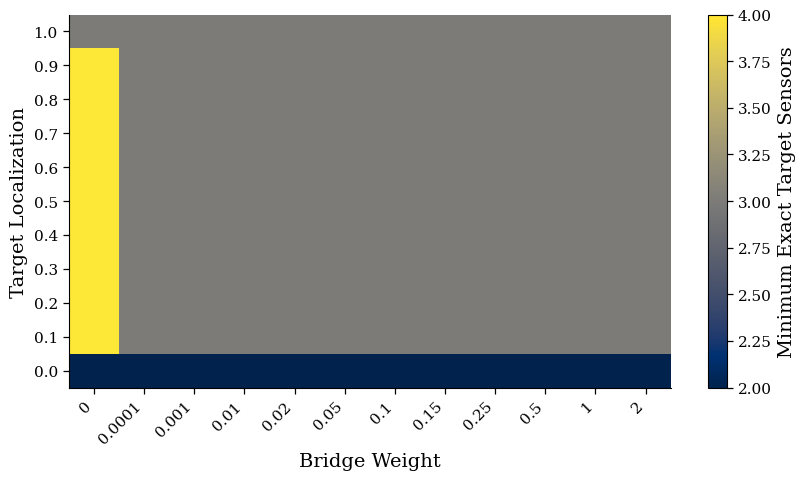

In [42]:
# Plot target budget phase
targetphase = structure.pivot(index="localization",columns="bridge",values="targetbudget")
fig, ax = plt.subplots(figsize=(8.5,5.0))
image = ax.imshow(targetphase.to_numpy(),origin="lower",aspect="auto",cmap="cividis",vmin=2,vmax=4)
ax.set_xticks(np.arange(len(targetphase.columns)))
ax.set_xticklabels([f"{value:g}" for value in targetphase.columns],rotation=45,ha="right")
ax.set_yticks(np.arange(len(targetphase.index)))
ax.set_yticklabels([f"{value:.1f}" for value in targetphase.index])
ax.set_xlabel("Bridge Weight")
ax.set_ylabel("Target Localization")
bar = fig.colorbar(image,ax=ax)
bar.set_label("Minimum Exact Target Sensors")
plt.tight_layout()
plt.savefig(out/"target_budget_phase.png",dpi=300,bbox_inches="tight",facecolor="white")
plt.show()


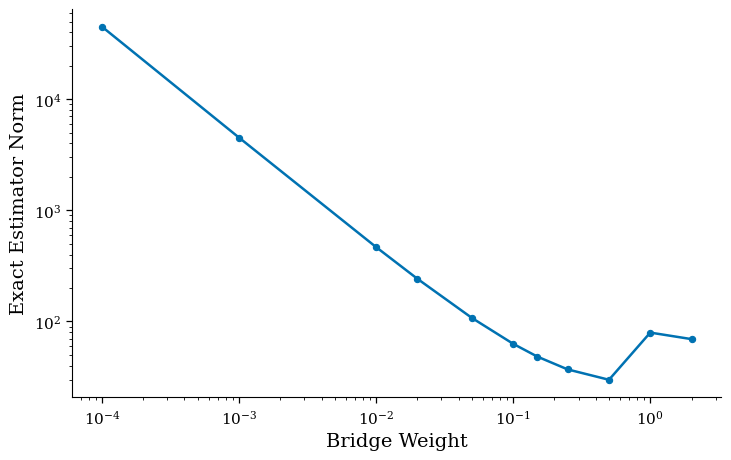

In [43]:
# Plot weak bridge instability
positive = bridgeframe[bridgeframe["bridge"]>0]
fig, ax = plt.subplots(figsize=(7.5,4.8))
ax.loglog(positive["bridge"],positive["bestexactnorm"],marker="o",color="#0072B2")
ax.set_xlabel("Bridge Weight")
ax.set_ylabel("Exact Estimator Norm")
plt.tight_layout()
plt.savefig(out/"weak_bridge_norm.png",dpi=300,bbox_inches="tight",facecolor="white")
plt.show()


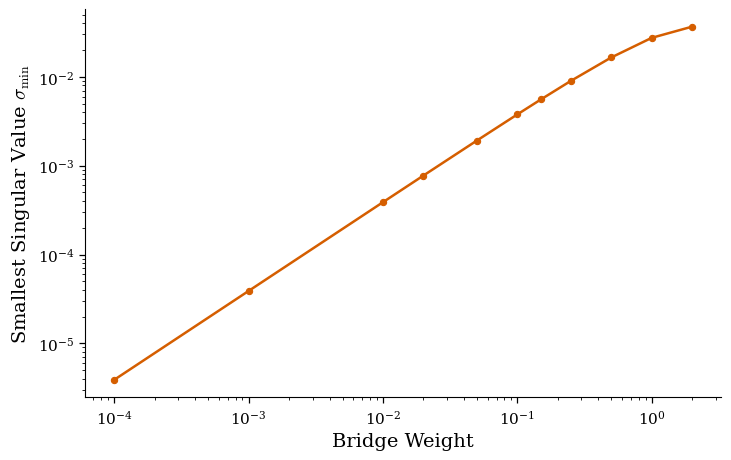

In [44]:
# Plot full state conditioning
positive = bridgeframe[bridgeframe["bridge"]>0]
fig, ax = plt.subplots(figsize=(7.5,4.8))
ax.loglog(positive["bridge"],positive["fullsmin"],marker="o",color="#D55E00")
ax.set_xlabel("Bridge Weight")
ax.set_ylabel(r"Smallest Singular Value $\sigma_{\min}$")
plt.tight_layout()
plt.savefig(out/"full_state_conditioning.png",dpi=300,bbox_inches="tight",facecolor="white")
plt.show()


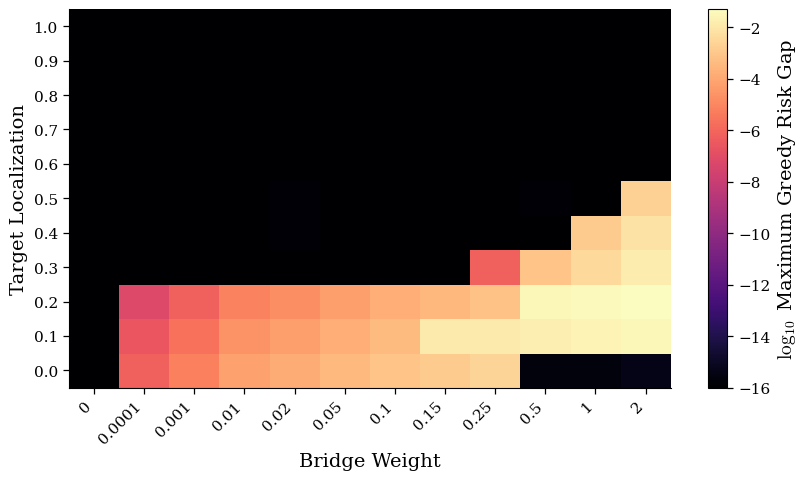

In [45]:
# Plot greedy risk failures
riskphase = structure.pivot(index="localization",columns="bridge",values="maxriskgap")
values = np.log10(np.maximum(riskphase.to_numpy(),1e-16))
fig, ax = plt.subplots(figsize=(8.5,5.0))
image = ax.imshow(values,origin="lower",aspect="auto",cmap="magma")
ax.set_xticks(np.arange(len(riskphase.columns)))
ax.set_xticklabels([f"{value:g}" for value in riskphase.columns],rotation=45,ha="right")
ax.set_yticks(np.arange(len(riskphase.index)))
ax.set_yticklabels([f"{value:.1f}" for value in riskphase.index])
ax.set_xlabel("Bridge Weight")
ax.set_ylabel("Target Localization")
bar = fig.colorbar(image,ax=ax)
bar.set_label(r"$\log_{10}$ Maximum Greedy Risk Gap")
plt.tight_layout()
plt.savefig(out/"greedy_risk_phase.png",dpi=300,bbox_inches="tight",facecolor="white")
plt.show()


In [46]:
# Select representative cases
choices = [("Weak-bridge instability",structure["bestexactnorm"].idxmax()),("Largest exact-budget excess",structure.sort_values(["riskexcess","maxriskgap"],ascending=[False,False]).index[0]),("Largest global-risk failure",structure["maxriskgap"].idxmax()),("Largest exchange failure",structure["maxrefinedgap"].idxmax()),("Largest exactness cost",structure["exactcost"].idxmax())]
rows = []
used = set()
for label,index in choices:
    if index not in used:
        row = structure.loc[index].to_dict()
        row["case"] = label
        rows.append(row)
        used.add(index)
representative = pd.DataFrame(rows)
display(representative[["case","bridge","localization","targetbudget","fullbudget","riskexact","spanexact","riskexcess","bestexactset","bestexactnorm","fullsmin","exactcost","maxriskgap","worstbudget","maxrefinedgap"]])


,case,bridge,localization,targetbudget,fullbudget,riskexact,spanexact,riskexcess,bestexactset,bestexactnorm,fullsmin,exactcost,maxriskgap,worstbudget,maxrefinedgap
0,Weak-bridge instability,0.0001,0.6,3,5,4,3,1,"(0, 1, 3)",317947.737308,0.000004,0.030280,1.387779e-17,7,1.387779e-17
1,Largest exact-budget excess,1.0000,0.1,3,5,5,3,2,"(0, 1, 4)",35.660887,0.027482,0.000000,2.360671e-02,5,2.360671e-02
2,Largest global-risk failure,2.0000,0.2,3,5,4,3,1,"(0, 1, 4)",46.120075,0.036733,0.000000,5.095107e-02,4,0.000000e+00
3,Largest exchange failure,2.0000,0.1,3,5,4,3,1,"(0, 1, 4)",49.587931,0.036733,0.000000,3.331609e-02,4,3.172490e-02
4,Largest exactness cost,0.0000,0.9,4,6,5,4,1,"(0, 1, 2, 7)",1.204253,0.126674,0.149809,2.775558e-17,7,2.775558e-17


In [47]:
# Save structural results
familygraphs.to_csv(out/"family_graphs.csv",index=False)
familycases.to_csv(out/"family_cases.csv",index=False)
familysummary.to_csv(out/"family_summary.csv",index=False)
baseline_subsets.to_csv(out/"baseline_subsets.csv",index=False)
baseline_risk.to_csv(out/"baseline_risk_greedy.csv",index=False)
baseline_span.to_csv(out/"baseline_span_greedy.csv",index=False)
baseline_compare.to_csv(out/"baseline_comparison.csv",index=False)
structure.to_csv(out/"localization_grid.csv",index=False)
highprecision.to_csv(out/"high_precision_grid.csv",index=False)
summary.to_csv(out/"verified_summary.csv",index=False)
weak.to_csv(out/"weak_bridge_scaling.csv",index=False)
representative.to_csv(out/"representative_cases.csv",index=False)
targetphase.to_csv(out/"target_budget_phase.csv")
structure.pivot(index="localization",columns="bridge",values="riskexcess").to_csv(out/"risk_excess_phase.csv")
structure.pivot(index="localization",columns="bridge",values="exactcost").to_csv(out/"exactness_cost_phase.csv")
riskphase.to_csv(out/"global_risk_gap_phase.csv")
structure.pivot(index="localization",columns="bridge",values="maxrefinedgap").to_csv(out/"exchange_gap_phase.csv")
parameters = {"vertices":n,"observation_times":obs.tolist(),"normalized_horizon":horizon,"exact_tolerance":tol,"family_horizons":familyhorizons,"bridge_values":bridges.tolist(),"localization_values":localizations.tolist(),"time_convention":"Each graph normalized by lambda max","regularization_rule":"0.01 times average full information trace"}
with open(out/"parameters.json","w") as file:
    json.dump(parameters,file,indent=2)
figures = ["target_budget_phase.png","weak_bridge_norm.png","full_state_conditioning.png","greedy_risk_phase.png"]
manifest = {"notebook":"03-structure.ipynb","consolidates":["03small.ipynb","04structure.ipynb"],"figures":figures,"tables":sorted(path.name for path in out.glob("*.csv"))}
with open(out/"manifest.json","w") as file:
    json.dump(manifest,file,indent=2)
archive = shutil.make_archive("structure","zip",out)
print("Saved:",archive)
print("Tables:",len(list(out.glob("*.csv"))))
print("Files:",len(list(out.iterdir())))


Saved: /content/structure.zip
Tables: 17
Files: 23


In [48]:
# Download structural archive
files.download("structure.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>